In [11]:
!pip install numpy matplotlib scikit-learn

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from time import time

MODELISATION ET ETUDE THEORIQUE

In [13]:
def gradient_ridge(X, y, w, mu):

    n = X.shape[0]
    residus = X @ w - y
    gradient = (1/n) * (X.T @ residus) + mu * w
    return gradient

def hess_ridge(X, mu):
    
    n, d = X.shape
    hess = (1/n) * (X.T @ X) + mu * np.eye(d)
    return hess

def cte_lip(X, mu):
    # SVD de X
    U, val_sing, Vt = np.linalg.svd(X, full_matrices=False)
    sigma_max = val_sing[0]  #val sing max
    
    n = X.shape[0]
    L = (sigma_max**2) / n + mu
    
    return L, sigma_max, val_sing

Appliquons ceci dans un exemple illustratif :

In [14]:
X1 = np.array([[1.0, 2.0], [2.0, 3.0], [3.0, 4.0]])
y1 = np.array([1.5, 2.5, 3.5])
w1 = np.array([0.5, 0.5])
mu1 = 0.1

gradient = gradient_ridge(X1, y1, w1, mu1)
hessian = hess_ridge(X1, mu1)
L, sigma_max, val_sing = cte_lip(X1, mu1)

print(f"\nValeurs singulières de X: {val_sing}")
print(f"σ_max = {sigma_max:.2f}")
print(f"Constante de Lipschitz L = {L:.2f}")



Valeurs singulières de X: [6.54675564 0.37415323]
σ_max = 6.55
Constante de Lipschitz L = 14.39


STOCHASTICITE ET PASSAGE A L'ECHELLE

In [15]:
#simulation d'une mise a jour
alpha_0 = 0.1
i = 0 
n = X1.shape[0]
k = 1 

#residu pour f_i(w)
residu = X1[i] @ w1 - y1[i]

#gradient stochastique g_k
g_k = X1[i] * residu + mu1 * w1

#pas
alpha_k = alpha_0 / (1 + k / n)

#maj
w = w1 - alpha_k * g_k

print(f"Résidu : {residu}")
print(f"Gradient g_k : {g_k}")
print(f"Pas alpha_k : {alpha_k}")
print(f"Ancien w : {w1}")
print(f"Nouveau w : {w}")

Résidu : 0.0
Gradient g_k : [0.05 0.05]
Pas alpha_k : 0.07500000000000001
Ancien w : [0.5 0.5]
Nouveau w : [0.49625 0.49625]


In [16]:
def sgd(X, y, mu, alpha_0, n_iter):
    
    n, d = X.shape
    w = np.zeros(d)
    
    history = {
        'weights': [w.copy()],
        'losses': [],
        'times': [0],
        'gradients_norm': []
    }
    
    start_time = time()
    
    for k in range(n_iter):
        #choisir un exple aleatoire
        i = np.random.randint(0, n)
        
        #gradient stochastique pour f_i(w)
        residu = X[i] @ w - y[i]
        g_k = X[i] * residu + mu * w
        
        #pas d'app decroissant
        alpha_k = alpha_0 / (1 + k / n)
        
        #maj
        w = w - alpha_k * g_k
        
        #historique
        if k % 100 == 0:
            loss = 0.5 * np.mean((X @ w - y)**2) + 0.5 * mu * np.sum(w**2)
            history['losses'].append(loss)
            history['weights'].append(w.copy())
            history['times'].append(time() - start_time)
            history['gradients_norm'].append(np.linalg.norm(g_k))
    
    # Dernière perte
    loss = 0.5 * np.mean((X @ w - y)**2) + 0.5 * mu * np.sum(w**2)
    history['losses'].append(loss)
    history['weights'].append(w.copy())
    history['times'].append(time() - start_time)
    
    return w, history

Mini-batch

In [17]:
#simulation

indices_test = [0, 1]
X_b = X1[indices_test]
y_b = y1[indices_test]
w_zero = np.array([0.0, 0.0])
g_test = gradient_ridge(X_b, y_b, w_zero, mu1)
w_b = w_zero - alpha_0 * g_test

print(f"Gradient g_test : {g_test}")
print(f"Ancien w : {w_zero}")
print(f"Nouveau w : {w_b}")

Gradient g_test : [-3.25 -5.25]
Ancien w : [0. 0.]
Nouveau w : [0.325 0.525]


In [18]:
def minibatch_gd(X, y, mu, alpha, n_iter, batch_size):
    
    n, d = X.shape
    w = np.zeros(d)
    
    history = {
        'losses': [],
        'times': [0]
    }
    
    start_time = time()
    
    for k in range(n_iter):
        #mini-batch aleatoire
        indices = np.random.choice(n, batch_size, replace=False)
        X_batch = X[indices]
        y_batch = y[indices]
        
        gradient = gradient_ridge(X_batch, y_batch, w, mu)
        w = w - alpha * gradient
        
        #historique
        if k % 10 == 0:
            loss = 0.5 * np.mean((X @ w - y)**2) + 0.5 * mu * np.sum(w**2)
            history['losses'].append(loss)
            history['times'].append(time() - start_time)
    
    loss = 0.5 * np.mean((X @ w - y)**2) + 0.5 * mu * np.sum(w**2)
    history['losses'].append(loss)
    history['times'].append(time() - start_time)
    
    return w, history

w_mb, history_mb = minibatch_gd(X1, y1, mu1, alpha=0.1, 
                                 n_iter=200, batch_size=2)
print(f"\nPoids finaux Mini-batch: {w_mb}")
print(f"Perte finale: {history_mb['losses'][-1]:.6f}")



Poids finaux Mini-batch: [0.4265448  0.55051509]
Perte finale: 0.024437


Comparaison mini-batch vs SGD

In [27]:
X = np.random.poisson(0.1, (5000, 500))
feature_names = [f"mot_{i}" for i in range(500)]
w_vrai = np.zeros(500)
b= 1998
bruit = np.random.normal(0, 5, 5000)
y= X @ w_vrai + b + bruit


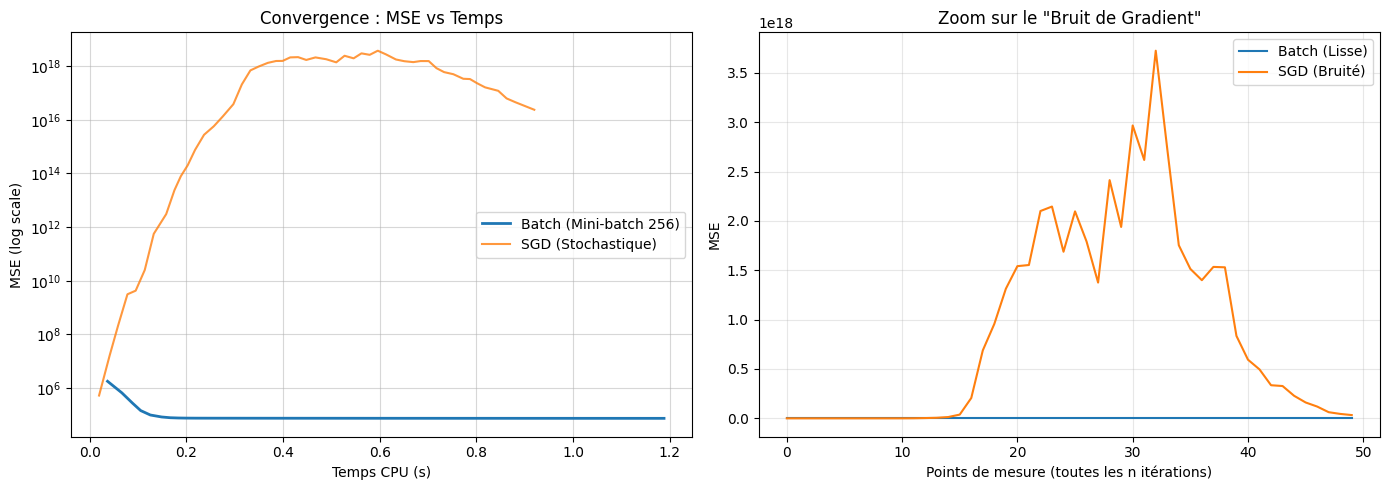

In [29]:
n_iter_batch = 500
n_iter_sgd = 5000  # Le SGD nécessite plus d'itérations mais est plus rapide par itération

w_batch, hist_batch = minibatch_gd(X, y, 0.1, alpha=0.01, n_iter=n_iter_batch, batch_size=256)
    
    
w_sgd, hist_sgd = sgd(X, y, 0.1, alpha_0=0.1, n_iter=n_iter_sgd)

    
plt.figure(figsize=(14, 5))

#MSE vs Temps CPU
plt.subplot(1, 2, 1)
plt.plot(hist_batch['times'][1:], hist_batch['losses'], label='Batch (Mini-batch 256)', lw=2)
plt.plot(hist_sgd['times'][1:], hist_sgd['losses'], label='SGD (Stochastique)', alpha=0.8)
plt.yscale('log')
plt.xlabel('Temps CPU (s)')
plt.ylabel('MSE (log scale)')
plt.title('Convergence : MSE vs Temps')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

#Illustration du "Bruit de Gradient"
plt.subplot(1, 2, 2)
plt.plot(range(len(hist_batch['losses'][:50])), hist_batch['losses'][:50], label='Batch (Lisse)')
plt.plot(range(len(hist_sgd['losses'][:50])), hist_sgd['losses'][:50], label='SGD (Bruité)')
plt.xlabel('Points de mesure (toutes les n itérations)')
plt.ylabel('MSE')
plt.title('Zoom sur le "Bruit de Gradient"')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Adam

In [33]:
def adam(X, y, mu, alpha, n_iter, beta1=0.9, beta2=0.999, epsilon=1e-8, 
         batch_size=32):
    
    n, d = X.shape
    w = np.zeros(d)
    m = np.zeros(d)  #moment d'ordre 1
    v = np.zeros(d)  #moment d'ordre 2
    
    history = {
        'losses': [],
        'times': [0]
    }
    
    start_time = time()
    
    for k in range(n_iter):
        indices = np.random.choice(n, min(batch_size, n), replace=False)
        X_batch = X[indices]
        y_batch = y[indices]
        
        gradient = gradient_ridge(X_batch, y_batch, w, mu)
        
        m = beta1 * m + (1 - beta1) * gradient
        v = beta2 * v + (1 - beta2) * (gradient**2)
        
        m_chap = m / (1 - beta1**(k+1))
        v_chap = v / (1 - beta2**(k+1))
        
        w = w - alpha * m_chap / (np.sqrt(v_chap) + epsilon)
        
        #historique
        if k % 10 == 0:
            loss = 0.5 * np.mean((X @ w - y)**2) + 0.5 * mu * np.sum(w**2)
            history['losses'].append(loss)
            history['times'].append(time() - start_time)
    
    # Dernière perte
    loss = 0.5 * np.mean((X @ w - y)**2) + 0.5 * mu * np.sum(w**2)
    history['losses'].append(loss)
    history['times'].append(time() - start_time)
    
    return w, history

w_adam, history_adam = adam(X, y, 0.1, alpha=0.1, 
                             n_iter=200, batch_size=2)
print(f"\nPoids finaux Adam: {w_adam}")
print(f"Perte finale: {history_adam['losses'][-1]:.6f}")


Poids finaux Adam: [ 7.97347338  7.56607032  8.55205512  7.12700849  6.96507004  8.57948497
  7.56723897  7.66000947  8.56660607  6.06125539  7.71530045  7.30467867
  6.86382631  8.89986367  6.97935029  6.87128451  7.22844565  8.04529821
  7.35732435  8.20041187  7.91856732  8.40186257  7.49685108  7.83474987
  8.59087497  8.25949219  7.99439515  7.70612095  7.44665466  7.58056988
  7.86050345  8.62254868  7.26930718  7.47075894  6.88036012  8.17743514
  7.79996023  7.63972991  8.55012081  8.40372046  7.48046503  7.13487666
  9.06965712  6.54588693  8.52942693  8.49876244  6.72561523  7.02753664
  7.51242433  8.98690399  8.77859247  7.0971187   7.98757467  8.32768546
  7.45974674  7.13158187  7.87943314  7.51037168  6.83890434  7.63972176
  7.6881774   6.38741692  6.732071    7.45677483  7.42083462  6.24664137
  7.55708094  9.58121191  7.47621247  6.64091227  6.80053242  8.38154377
  6.79309179  8.22993037  9.40448772  9.44570189  6.90144869  5.73198196
  8.14461779 10.02917188  8.126

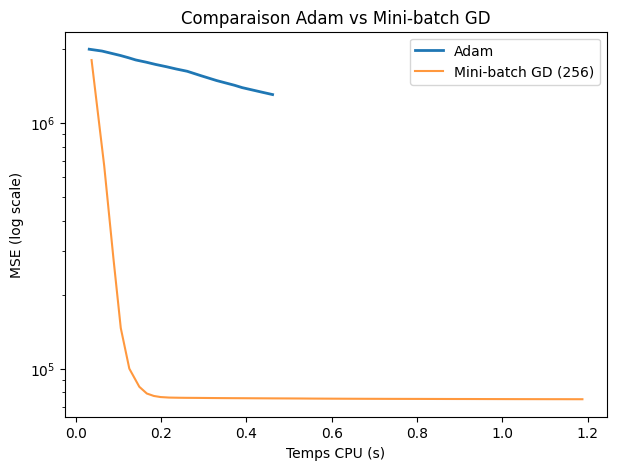

In [34]:
#comparaison Adam et Mini-batch GD
plt.figure(figsize=(7, 5))
plt.plot(history_adam['times'][1:], history_adam['losses'], label='Adam', lw=2)
plt.plot(hist_batch['times'][1:], hist_batch['losses'], label='Mini-batch GD (256)', alpha=0.8)
plt.yscale('log')
plt.xlabel('Temps CPU (s)')
plt.ylabel('MSE (log scale)')
plt.title('Comparaison Adam vs Mini-batch GD')
plt.legend()
plt.show()


PARCIMONIE ET ALGORITHMES PROXIMAUX

In [21]:
def soft_thresholding(v, lambda_param):
    return np.sign(v) * np.maximum(np.abs(v) - lambda_param, 0)

#exple
v_example = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
lambda_exple = 0.8

print(f"entree v: {v_example}")
print(f"lambda: {lambda_exple}")
print(f"Operateur prox: {soft_thresholding(v_example, lambda_exple)}")

entree v: [-2.  -0.5  0.   0.5  2. ]
lambda: 0.8
Operateur prox: [-1.2 -0.   0.   0.   1.2]


In [22]:
def ista(X, y, lambda_param, n_iter):
    
    n, d = X.shape
    w = np.zeros(d)
    
    # Calculer la constante de Lipschitz
    L, _, _ = cte_lip(X, 0)
    alpha = 1 / L  # Pas optimal
    
    history = {
        'weights': [w.copy()],
        'losses': [],
        'sparsity': [],  #nbre de coeffs non nuls
        'times': [0]
    }
    
    start_time = time()
    
    for k in range(n_iter):
        gradient = (1/n) * X.T @ (X @ w - y)
        v = w - alpha * gradient
        
        #operateur prox
        w = soft_thresholding(v, alpha * lambda_param)
        
        #historique
        if k % 10 == 0:
            loss = 0.5 * np.mean((X @ w - y)**2) + lambda_param * np.sum(np.abs(w))
            sparsity = np.sum(np.abs(w) > 1e-6)
            
            history['weights'].append(w.copy())
            history['losses'].append(loss)
            history['sparsity'].append(sparsity)
            history['times'].append(time() - start_time)
    
    loss = 0.5 * np.mean((X @ w - y)**2) + lambda_param * np.sum(np.abs(w))
    sparsity = np.sum(np.abs(w) > 1e-6)
    history['weights'].append(w.copy())
    history['losses'].append(loss)
    history['sparsity'].append(sparsity)
    history['times'].append(time() - start_time)
    
    return w, history

# Exemple ISTA
w_ista, history_ista = ista(X1, y1, lambda_param=0.1, 
                             n_iter=500)
print(f"\nPoids finaux ISTA: {w_ista}")
print(f"Perte finale: {history_ista['losses'][-1]:.6f}")
print(f"Nombre de coefficients non nuls: {history_ista['sparsity'][-1]}")


Poids finaux ISTA: [0.11637841 0.75399973]
Perte finale: 0.092652
Nombre de coefficients non nuls: 2


FISTA


In [24]:
def fista(X, y, lambda_param, n_iter):
    n, d = X.shape
    w = np.zeros(d)
    z = np.zeros(d)  #interpolation
    t = 1 
    
    L, _, _ = cte_lip(X, 0)
    alpha = 1 / L
    
    history = {
        'weights': [w.copy()],
        'losses': [],
        'sparsity': [],
        'times': [0]
    }
    
    start_time = time()
    
    for k in range(n_iter):
        w_old = w.copy()
        
        #grad z
        gradient = (1/n) * X.T @ (X @ z - y)
        v = z - alpha * gradient
        
        w = soft_thresholding(v, alpha * lambda_param)
        
        #maj accélération
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        
        #Nesterov
        z = w + ((t - 1) / t_new) * (w - w_old)
        
        t = t_new
        
        #historique
        if k % 10 == 0:
            loss = 0.5 * np.mean((X @ w - y)**2) + lambda_param * np.sum(np.abs(w))
            sparsity = np.sum(np.abs(w) > 1e-6)
            
            history['weights'].append(w.copy())
            history['losses'].append(loss)
            history['sparsity'].append(sparsity)
            history['times'].append(time() - start_time)
    
    loss = 0.5 * np.mean((X @ w - y)**2) + lambda_param * np.sum(np.abs(w))
    sparsity = np.sum(np.abs(w) > 1e-6)
    history['weights'].append(w.copy())
    history['losses'].append(loss)
    history['sparsity'].append(sparsity)
    history['times'].append(time() - start_time)
    
    return w, history

#exple
w_fista, history_fista = fista(X1, y1, lambda_param=0.1, 
                                n_iter=500)
print(f"\nPoids finaux FISTA: {w_fista}")
print(f"Perte finale: {history_fista['losses'][-1]:.6f}")
print(f"Nombre de coefficients non nuls: {history_fista['sparsity'][-1]}")



Poids finaux FISTA: [0.05056145 0.79961091]
Perte finale: 0.092500
Nombre de coefficients non nuls: 2
